### Tutorial

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalNumber: int

In [4]:
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber"] = state["number1"] - state["number2"]

    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"

In [5]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state: state)   #Passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

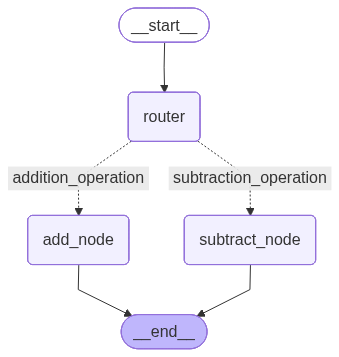

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
result = app.invoke({"number1": 12, "operation": "+", "number2": 5})
print(result)

{'number1': 12, 'operation': '+', 'number2': 5, 'finalNumber': 17}


In [12]:
# Other method of invoking
initial_state_1 = AgentState(number1 = 10, operation = "-", number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


### My Turn

In [2]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END

In [25]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation1: str
    number3: int
    number4: int
    operation2: str
    finalNumber1: int
    finalNumber2: int

In [31]:
def adder1(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber1"] = state["number1"] + state["number2"]

    return state

def subtractor1(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber1"] = state["number1"] - state["number2"]

    return state

def adder2(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber2"] = state["number3"] + state["number4"]

    return state

def subtractor2(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""

    state["finalNumber2"] = state["number3"] - state["number4"]

    return state

def decide_next_node1(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation1"] == "+":
        return "addition_operation1"
    elif state["operation1"] == "-":
        return "subtraction_operation1"

def decide_next_node2(state: AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation2"] == "+":
        return "addition_operation2"
    elif state["operation2"] == "-":
        return "subtraction_operation2"
    

In [32]:
graph = StateGraph(AgentState)

graph.add_node("add_node1", adder1)
graph.add_node("subtract_node1", subtractor1)
graph.add_node("router1", lambda state: state)   #Passthrough function
graph.add_node("router2", lambda state: state)   #Passthrough function
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)

graph.add_edge(START, "router1")

graph.add_conditional_edges(
    "router1",
    decide_next_node1,
    {
        "addition_operation1": "add_node1",
        "subtraction_operation1": "subtract_node1"
    }
)

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }
)

graph.add_edge("add_node1", "router2")
graph.add_edge("subtract_node1", "router2")

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

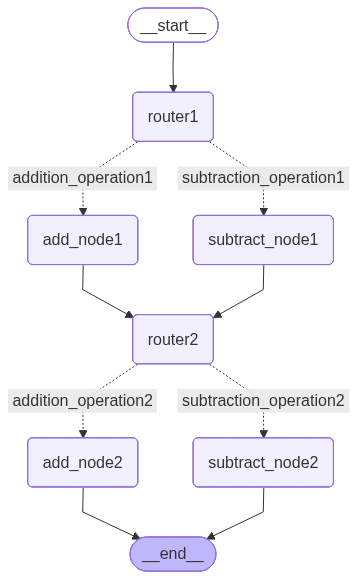

In [33]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [34]:
result = app.invoke({"number1": 100, "number2": 4, "operation1": "+", "number3": 400, "number4": 9, "operation2": "-"})

In [35]:
print(result)

{'number1': 100, 'number2': 4, 'operation1': '+', 'number3': 400, 'number4': 9, 'operation2': '-', 'finalNumber1': 104, 'finalNumber2': 391}
